<a href="https://www.kaggle.com/code/sonawanelalitsunil/screentime-trends-indian-kids-in-2025-ml-100?scriptVersionId=249520126" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-kids-screentime-2025/Indian_Kids_Screen_Time.csv


## Title:
"Screentime Trends Among Indian Kids in 2025"

## Description:
In 2025, screen time among Indian children has reached new heights, influenced by the rise of digital learning, social media, and entertainment apps. This report delves into the average daily screen usage by age group, regional variations, and the types of content most consumed by kids. It also highlights concerns raised by parents and experts around mental health, physical activity, and academic performance. As India continues its digital transformation, understanding and managing children's screen habits is more important than ever.

In [2]:
df = pd.read_csv('/kaggle/input/indian-kids-screentime-2025/Indian_Kids_Screen_Time.csv')

In [3]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [7]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [8]:
df.duplicated().sum()

44

In [9]:
df.dtypes

Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
dtype: object

In [10]:
df.shape

(9712, 8)

In [11]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

## Data visualizations

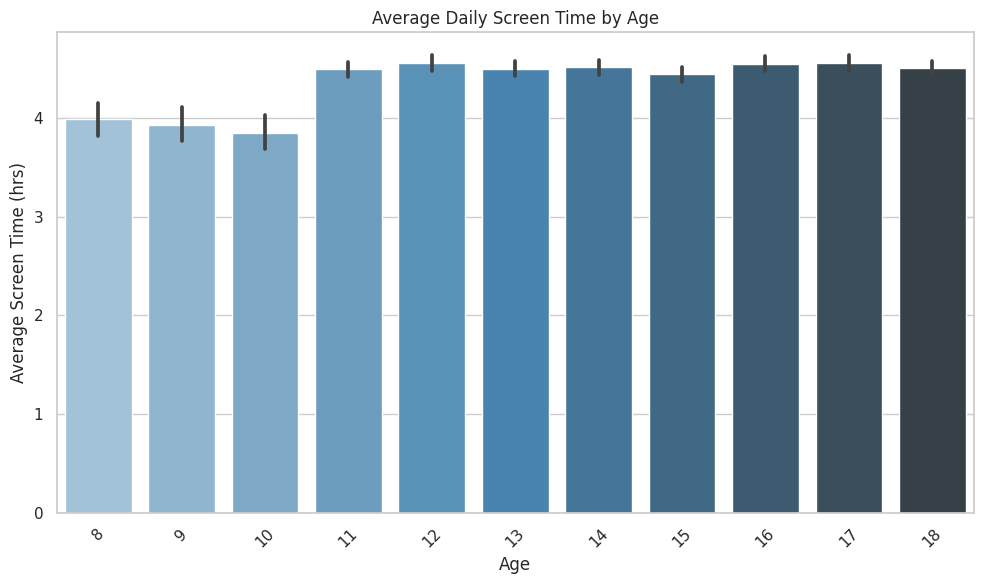

In [12]:
# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Average Screen Time by Age
sns.barplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df, palette='Blues_d')
plt.title('Average Daily Screen Time by Age')
plt.xlabel('Age')
plt.ylabel('Average Screen Time (hrs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

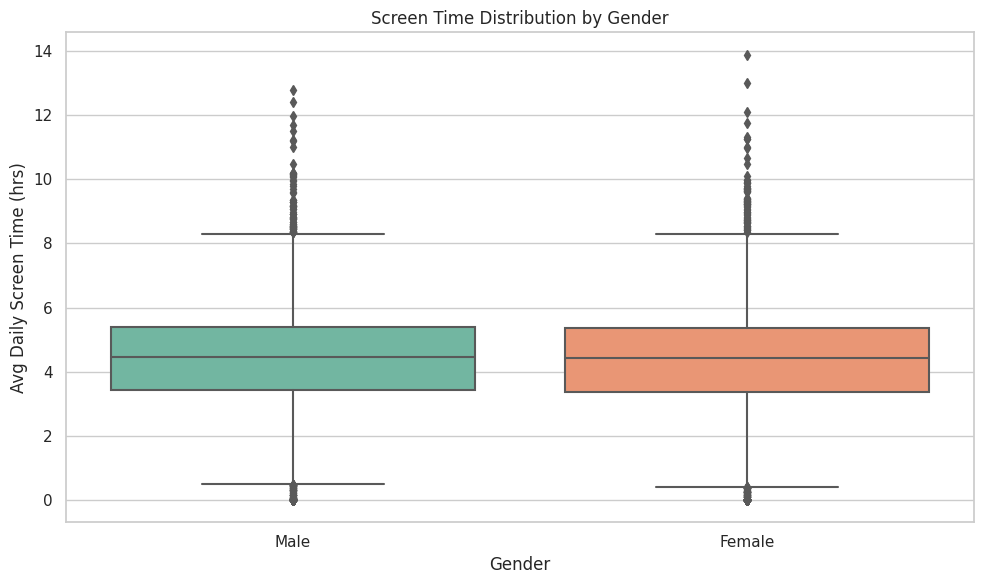

In [13]:
# 2. Screen Time Distribution by Gender
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set2')
plt.title('Screen Time Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Avg Daily Screen Time (hrs)')
plt.tight_layout()
plt.show()

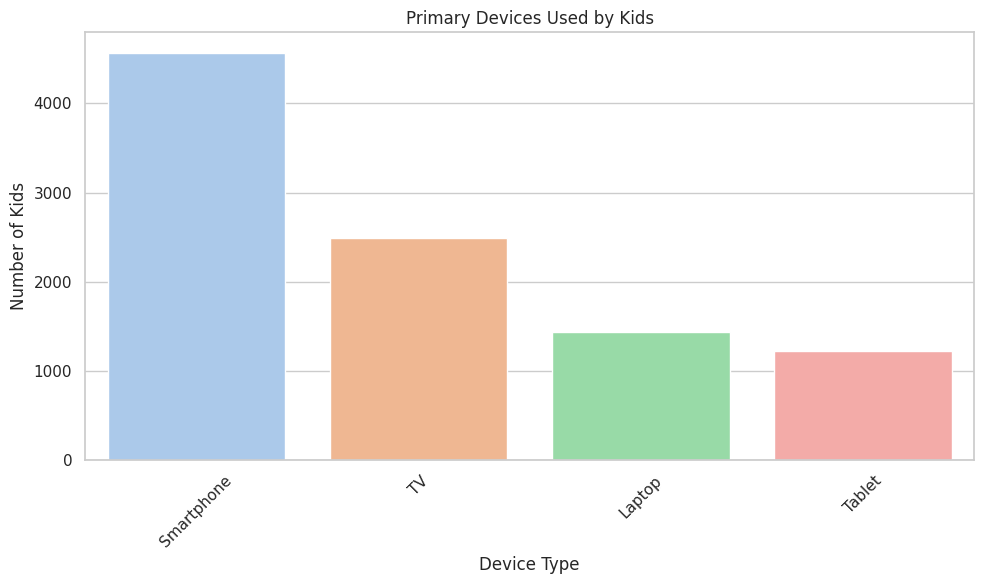

In [14]:
# 3. Primary Device Usage
sns.countplot(data=df, x='Primary_Device', order=df['Primary_Device'].value_counts().index, palette='pastel')
plt.title('Primary Devices Used by Kids')
plt.xlabel('Device Type')
plt.ylabel('Number of Kids')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

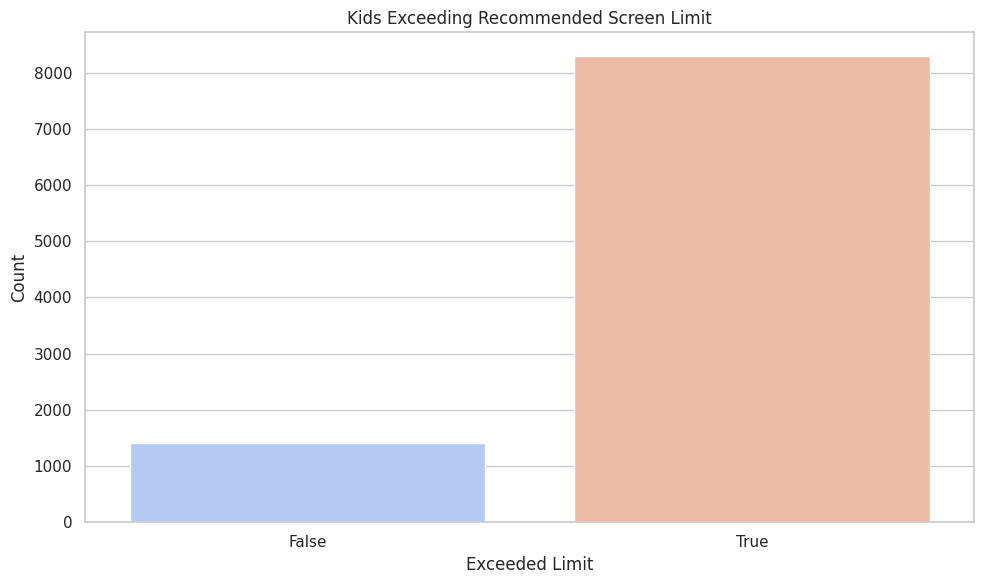

In [15]:
# 4. Exceeded Recommended Screen Limit (Yes/No)
sns.countplot(data=df, x='Exceeded_Recommended_Limit', palette='coolwarm')
plt.title('Kids Exceeding Recommended Screen Limit')
plt.xlabel('Exceeded Limit')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

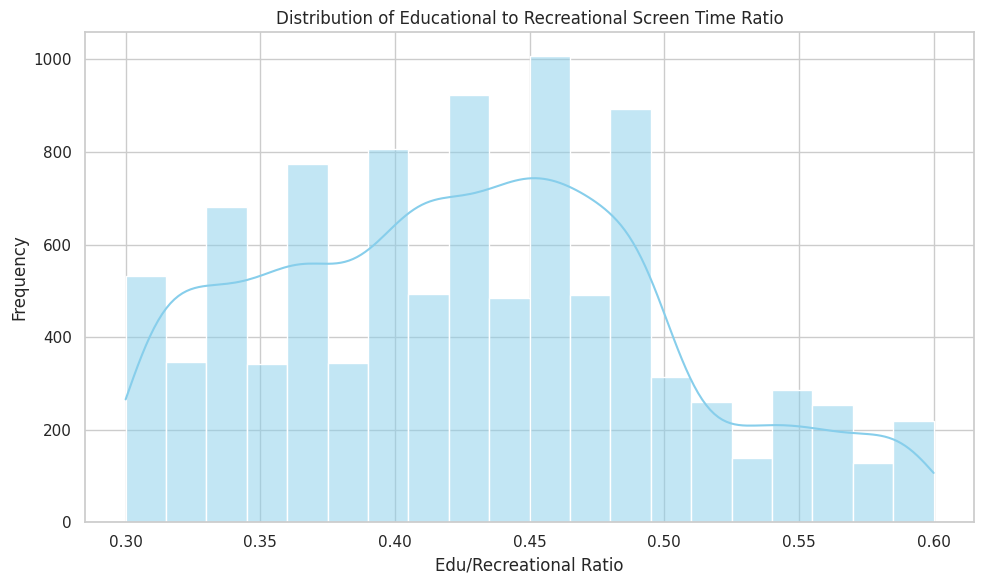

In [16]:
# 5. Educational vs Recreational Usage (Ratio)
sns.histplot(df['Educational_to_Recreational_Ratio'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Educational to Recreational Screen Time Ratio')
plt.xlabel('Edu/Recreational Ratio')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

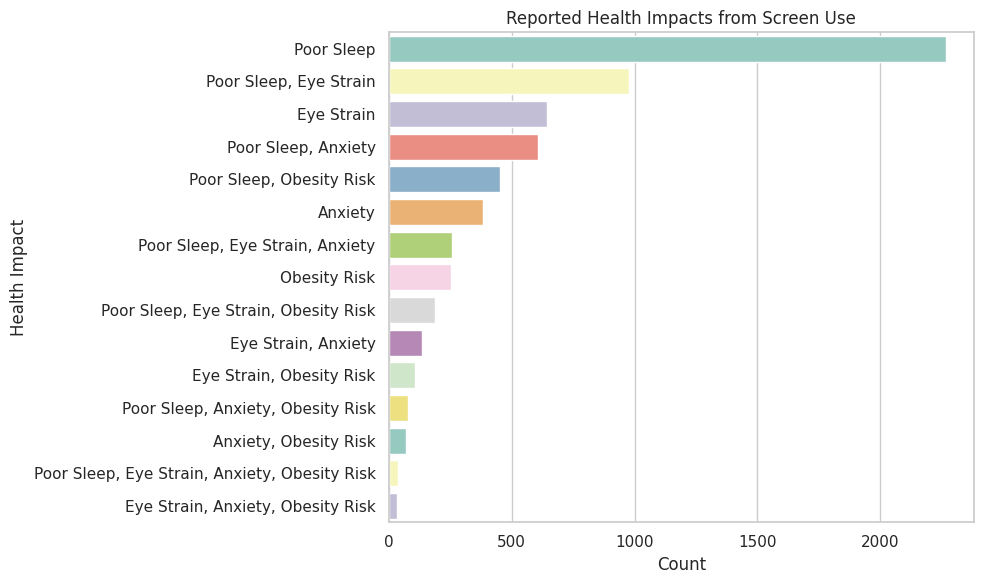

In [17]:
# 6. Health Impacts Distribution
sns.countplot(y='Health_Impacts', data=df, order=df['Health_Impacts'].value_counts().index, palette='Set3')
plt.title('Reported Health Impacts from Screen Use')
plt.xlabel('Count')
plt.ylabel('Health Impact')
plt.tight_layout()
plt.show()

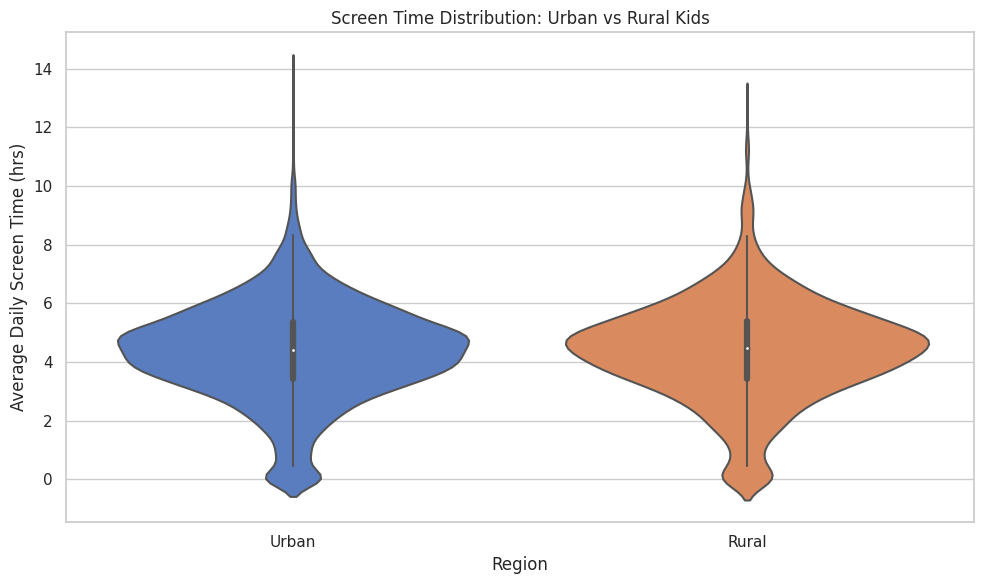

In [18]:
# 7. Urban vs Rural Screen Time Comparison
sns.violinplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df, palette='muted')
plt.title('Screen Time Distribution: Urban vs Rural Kids')
plt.xlabel('Region')
plt.ylabel('Average Daily Screen Time (hrs)')
plt.tight_layout()
plt.show()


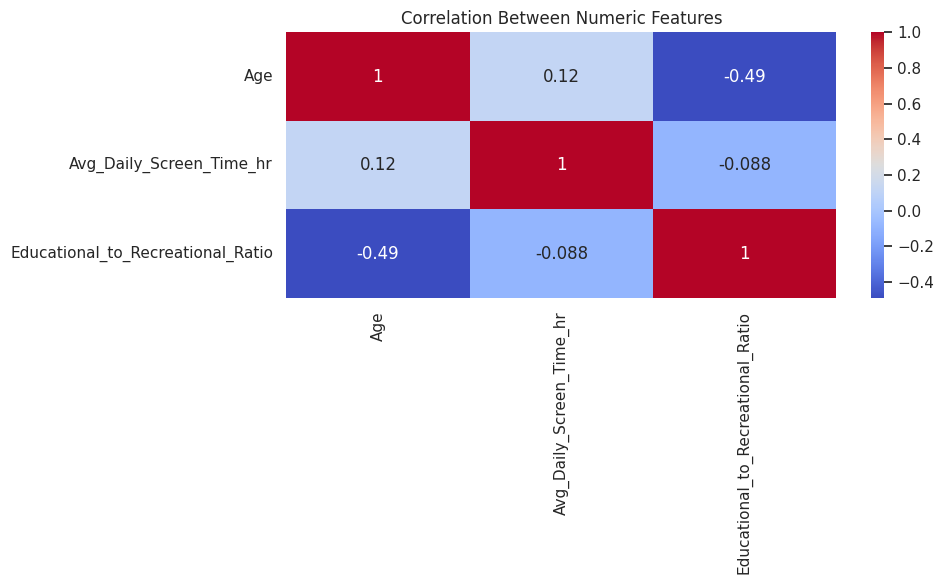

In [19]:
# 8. Heatmap: Correlation Matrix
corr = df[['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [21]:
categorical_cols = ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural', 'Exceeded_Recommended_Limit']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [22]:
# Define features and target
X = df.drop('Exceeded_Recommended_Limit', axis=1)
y = df['Exceeded_Recommended_Limit']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}


Logistic Regression: 97.63% accuracy
Random Forest: 100.00% accuracy
Decision Tree: 100.00% accuracy
Naive Bayes: 83.63% accuracy
SVM: 98.25% accuracy
KNN: 98.61% accuracy


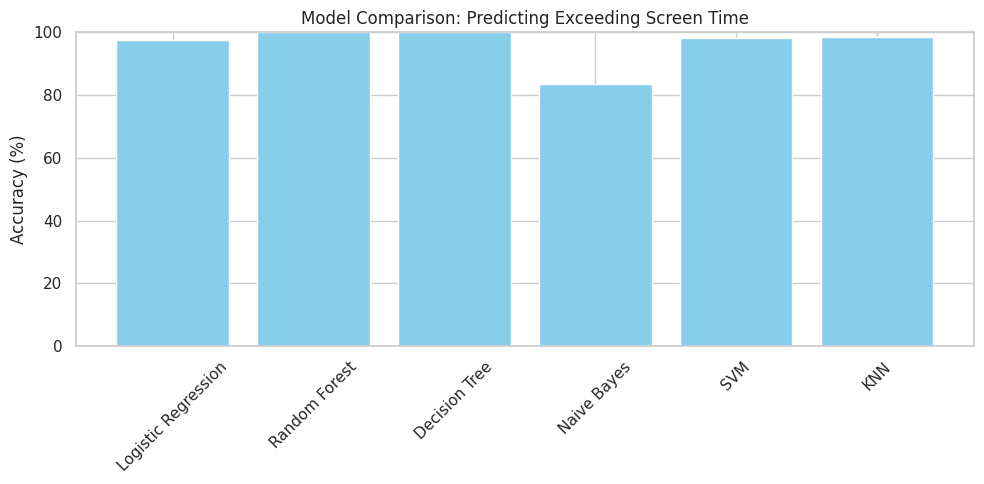

In [23]:
# Evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc * 100  # percentage

# Show accuracy results
for model, acc in results.items():
    print(f"{model}: {acc:.2f}% accuracy")

# Bar chart of results
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison: Predicting Exceeding Screen Time')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Thank you ..pls upvote!!!